# MNIST: k-Means Clustering and Cluster-Center Visualization

## Project Overview

This notebook applies k-means clustering to normalized MNIST image vectors and visualizes the learned cluster centers in the original 28×28 image geometry.

Thirty clusters are fitted to the 60,000 training images, allowing multiple prototype patterns to emerge across the handwritten-digit dataset.

### Technical Coverage

- MNIST preprocessing
- image flattening
- normalization
- k-means clustering
- 30-cluster model
- cluster assignments
- learned centroid inspection
- image-space centroid visualization

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.cluster import KMeans

## 2. MNIST Data Preparation

The 28×28 images are normalized to `[0, 1]` and flattened into 784-dimensional vectors.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = (x_train/255.0).reshape(-1,784)
x_test = (x_test/255.0).reshape(-1,784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 3. Thirty-Cluster k-Means Model

The model uses 30 clusters with a fixed random state for reproducibility.

In [3]:
kmeans = KMeans(n_clusters=30, random_state=0, n_init="auto")
kmeans.fit(x_train)

KMeans(n_clusters=30, random_state=0)

### Training-Image Cluster Assignments

In [4]:
kmeans.labels_

array([13,  7, 11, ..., 13, 15, 25], dtype=int32)

## 4. Learned Cluster Centers

Each 784-dimensional centroid is reshaped back to 28×28 pixels. The 30 learned centers are displayed in a 3×10 grid, providing visual prototypes of the image groups discovered by k-means.

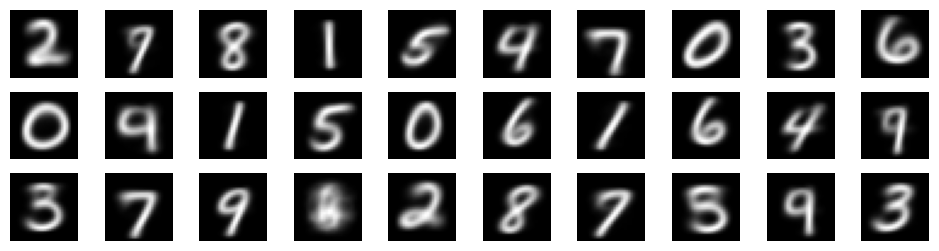

In [5]:
fig, ax = plt.subplots(3, 10, figsize=(12,3))
for i in range(30):
  ax[i//10,i%10].imshow(kmeans.cluster_centers_[i].reshape(28,28), cmap = "gray")
  ax[i//10,i%10].axis("off")

## 5. Key Findings

- k-means can be applied directly to flattened image vectors as an unsupervised clustering method.
- Using 30 clusters allows the model to learn multiple prototypes rather than forcing one centroid per digit class.
- Reshaping cluster centers back into image space makes the learned groups interpretable as handwritten-digit-like patterns.